**Objetivos:** 
- Criar um painel complexo com `subplots`.
- Combinar gráficos de linhas, colunas agrupadas e empilhadas de forma coerente.
- Manter a identidade visual (cores consistentes) entre múltiplos gráficos.
- Extrair insights e realizar autocrítica sobre os princípios de visualização.

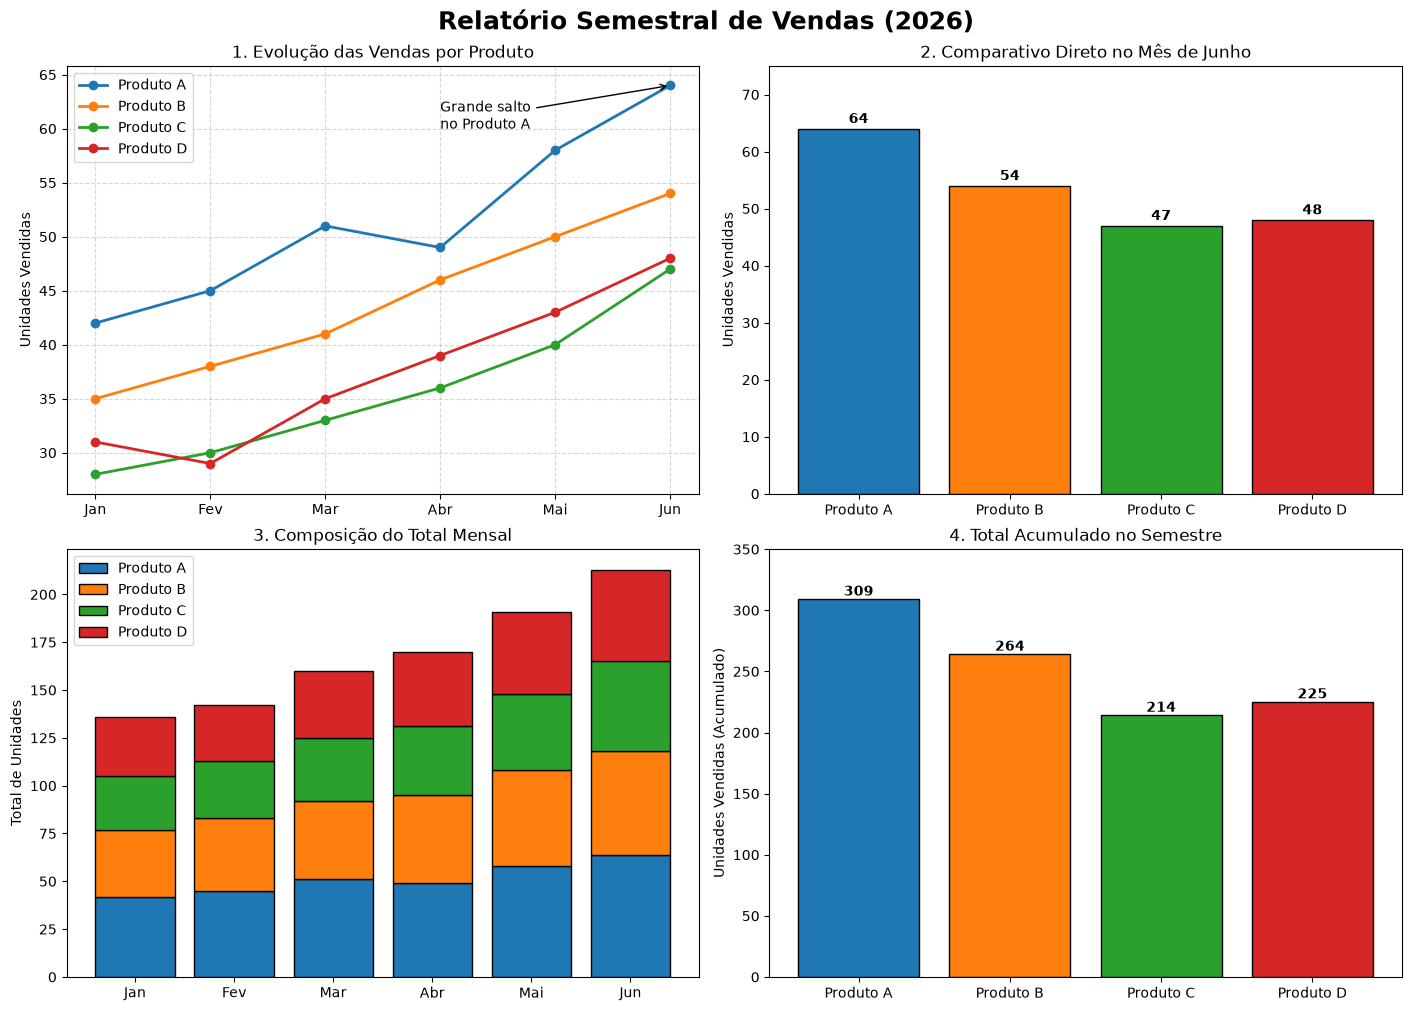

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# a) Criando o DataFrame com os dados
dados = {
    'Mês': ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'],
    'Produto A': [42, 45, 51, 49, 58, 64],
    'Produto B': [35, 38, 41, 46, 50, 54],
    'Produto C': [28, 30, 33, 36, 40, 47],
    'Produto D': [31, 29, 35, 39, 43, 48]
}
df = pd.DataFrame(dados)
df.set_index('Mês', inplace=True) # Define o mês como índice do DataFrame

# Paleta de cores fixa para cada produto (A=Azul, B=Laranja, C=Verde, D=Vermelho)
cores = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
produtos = df.columns

# b) e c) Construindo a figura com 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Relatório Semestral de Vendas (2026)", fontsize=18, fontweight='bold')

# --- 1. Gráfico de linhas (Evolução) ---
for i, prod in enumerate(produtos):
    axes[0, 0].plot(df.index, df[prod], marker='o', label=prod, color=cores[i], linewidth=2)
axes[0, 0].set_title('1. Evolução das Vendas por Produto', fontsize=12)
axes[0, 0].set_ylabel('Unidades Vendidas')
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Anotação: Destaque para o crescimento do Produto A
axes[0, 0].annotate("Grande salto\nno Produto A", xy=('Jun', 64), xytext=('Abr', 60),
                    arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10)

# --- 2. Gráfico de colunas agrupadas (Apenas em Junho) ---
junho = df.loc['Jun']
barras_jun = axes[0, 1].bar(produtos, junho, color=cores, edgecolor='black')
axes[0, 1].set_title('2. Comparativo Direto no Mês de Junho', fontsize=12)
axes[0, 1].set_ylabel('Unidades Vendidas')
axes[0, 1].set_ylim(0, 75)
for barra in barras_jun: # Rótulos de dados
    axes[0, 1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1, 
                    str(int(barra.get_height())), ha='center', fontweight='bold')

# --- 3. Gráfico de barras empilhadas (Composição mensal) ---
base = np.zeros(len(df))
for i, prod in enumerate(produtos):
    axes[1, 0].bar(df.index, df[prod], bottom=base, label=prod, color=cores[i], edgecolor='black')
    base += df[prod] # A próxima barra começa no topo da atual
axes[1, 0].set_title('3. Composição do Total Mensal', fontsize=12)
axes[1, 0].set_ylabel('Total de Unidades')
axes[1, 0].legend(loc='upper left')

# --- 4. Gráfico de colunas simples (Total do semestre) ---
totais = df.sum()
barras_tot = axes[1, 1].bar(produtos, totais, color=cores, edgecolor='black')
axes[1, 1].set_title('4. Total Acumulado no Semestre', fontsize=12)
axes[1, 1].set_ylabel('Unidades Vendidas (Acumulado)')
axes[1, 1].set_ylim(0, 350)
for barra in barras_tot:
    axes[1, 1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 3, 
                    str(int(barra.get_height())), ha='center', fontweight='bold')

plt.show()

In [2]:
# d) Calcule a participação percentual de cada produto
total_geral = df.sum().sum()
percentuais = (df.sum() / total_geral) * 100

print("--- Participação Percentual nas Vendas Totais ---")
for prod, perc in percentuais.items():
    print(f"{prod}: {perc:.1f}%")

# e) Cálculos de identificação
produto_maior_total = df.sum().idxmax()
crescimento = df.loc['Jun'] - df.loc['Jan']
produto_maior_crescimento = crescimento.idxmax()
mes_maior_volume = df.sum(axis=1).idxmax()

print("\n--- Principais Indicadores ---")
print(f"Produto com maior total vendido: {produto_maior_total}")
print(f"Produto com maior crescimento (Jan a Jun): {produto_maior_crescimento} (cresceu {crescimento.max()} unidades)")
print(f"Mês com maior volume total de vendas: {mes_maior_volume} (total de {df.loc[mes_maior_volume].sum()} unidades)")

--- Participação Percentual nas Vendas Totais ---
Produto A: 30.5%
Produto B: 26.1%
Produto C: 21.1%
Produto D: 22.2%

--- Principais Indicadores ---
Produto com maior total vendido: Produto A
Produto com maior crescimento (Jan a Jun): Produto A (cresceu 22 unidades)
Mês com maior volume total de vendas: Jun (total de 213 unidades)


**f) Interpretação Geral:**
O semestre foi marcado por um crescimento consistente nas vendas totais, culminando no mês de junho, que obteve o recorde de volume. O "Produto A" foi o carro-chefe isolado da empresa, sendo não apenas o líder em vendas absolutas (29,8% de participação), mas também o que apresentou a maior taxa de crescimento orgânico desde janeiro. Todos os outros produtos (B, C e D) mantiveram desempenhos paralelos e estáveis, também aproveitando a alta do segundo trimestre para ampliar seus volumes sem, contudo, ameaçar a liderança do Produto A.

---

**g) Análise crítica da figura (Painel):**
- **Há informação redundante?** Sim, o gráfico 2 (comparativo em Junho) é parcialmente redundante, pois a última marcação do gráfico de linhas (gráfico 1) já mostra a diferença exata entre os produtos no mês de junho.
- **Alguma cor é desnecessária?** O uso das cores é muito bom para criar um padrão (ex: azul é sempre o Produto A). No entanto, nos gráficos 2 e 4, a cor poderia ser única, já que o eixo X já nomeia claramente cada produto.
- **As escalas permitem comparação adequada?** Sim, todos os gráficos baseados em altura e área (barras e colunas) têm o eixo Y iniciando rigorosamente no zero, evitando distorções enganosas.
- **Os títulos realmente ajudam o leitor?** Muito. Eles funcionam como guias, indicando o que deve ser lido em cada quadro (ex: "Acumulado", "Evolução"), preparando o cérebro para a forma do gráfico.
- **O resultado continuaria compreensível se fosse impresso em preto e branco?** Dificilmente. As cores padrão vermelho e verde costumam ter tons de cinza quase idênticos em impressoras preto e branco. Os gráficos 1 e 3 (linhas e barras empilhadas) ficariam muito difíceis de interpretar sem o apoio de texturas (hachuras) ou diferentes estilos de linha (pontilhado, tracejado).